In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv(r"..\data\raw\global_craft_brewery_database_2026.csv")
df.head()

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,...,website_url,longitude,latitude,has_website,has_phone,has_coordinates,name_length,hemisphere,lng_band,brewery_tier
0,ae7b3174-8be8-4d53-a3a5-9b8240970eea,'s,brewpub,1 Friesener Straße,NaN,NaN,Kronach,Bayern,96317,Germany,...,http://www.antla.de,11.327765,50.241246,1,1,1,2,Northern,E_Near,Hospitality
1,5128df48-79fc-4f0f-8b52-d06be54d0cec,(405) Brewing Co,micro,1716 Topeka St,NaN,NaN,Norman,Oklahoma,73069-8224,United States,...,http://www.405brewing.com,-97.468182,35.257389,1,1,1,16,Northern,W_Far,Independent
2,9c5a66c8-cc13-416f-a5d9-0a769c87d318,(512) Brewing Co,micro,407 Radam Ln Ste F200,NaN,NaN,Austin,Texas,78745-1197,United States,...,http://www.512brewing.com,NaN,NaN,1,1,0,16,Southern,NaN,Independent
3,34e8c68b-6146-453f-a4b9-1f6cd99a5ada,1 of Us Brewing Company,micro,8100 Washington Ave,NaN,NaN,Mount Pleasant,Wisconsin,53406-3920,United States,...,https://www.1ofusbrewing.com,-87.883364,42.720108,1,1,1,23,Northern,W_Near,Independent
4,21f21cc0-5b2f-4b79-be29-3bc625bcc4c8,1. Altenberger Brauhaus,brewpub,18 Zirndorfer Straße,NaN,NaN,Oberasbach,Bayern,90522,Germany,...,http://www.altenberger-brauhaus.de,10.968559,49.436996,1,1,1,23,Northern,E_Near,Hospitality


In [10]:
df.tail()

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,...,website_url,longitude,latitude,has_website,has_phone,has_coordinates,name_length,hemisphere,lng_band,brewery_tier
11025,57a70f5c-a995-4be1-949c-99244450940f,플레이그라운드 브루어리(playground Brewery),brewpub,"246-13, Isanpo-gil",Ilsanseo-gu,NaN,Goyang-si,Gyeonggido,10203,South Korea,...,https://www.playgroundbrewery.com/,126.702011,37.667795,1,1,1,32,Northern,E_Far,Hospitality
11026,64a4f65c-47a9-4d8e-ad2e-3cc898b9689c,핸드앤몰트 (Hand and Malt),brewpub,"19, Hangang-daero 38ga-gil",NaN,NaN,Yongsan-gu,Seoul,04386,South Korea,...,http://handandmalt.com/,126.970583,37.529857,1,1,1,21,Northern,E_Far,Hospitality
11027,a9541aa9-5c12-469b-8cbb-01fb5619cefc,허심청브루잉(Hursimchung Bru),brewpub,"23, Geumganggongwon-ro 20beon-gil",NaN,NaN,Dongnae-gu,Busan,47709,South Korea,...,https://www.hotelnongshim.com/kr/index.php?pCo...,129.082603,35.219902,1,1,1,23,Northern,E_Far,Hospitality
11028,6f317bdc-458e-466f-bd2a-9ab398d46631,헤이스탁 브루어리(Haystack Brewery),brewpub,"25, Pangyogongwon-ro 3-gil",Bundang-gu,NaN,Seongnam-si,Gyeonggido,13477,South Korea,...,NaN,127.089061,37.391256,0,1,1,27,Northern,E_Far,Hospitality
11029,a1308963-b966-49f7-8f84-97ba37775d14,화이트크로우 브루잉(Whitecrow Brewing),brewpub,"65,Gowon-ro",Bangnim-myeon,NaN,Pyeongchang-gun,Gangwondo,25364,South Korea,...,https://www.instagram.com/whitecrowbrewing/,128.251542,37.475984,1,1,1,29,Northern,E_Far,Hospitality


In [11]:
df.shape

(11030, 21)

In [12]:
df.columns

Index(['id', 'name', 'brewery_type', 'address_1', 'address_2', 'address_3',
       'city', 'state_province', 'postal_code', 'country', 'phone',
       'website_url', 'longitude', 'latitude', 'has_website', 'has_phone',
       'has_coordinates', 'name_length', 'hemisphere', 'lng_band',
       'brewery_tier'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11030 entries, 0 to 11029
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               11030 non-null  object 
 1   name             11030 non-null  object 
 2   brewery_type     11030 non-null  object 
 3   address_1        10294 non-null  object 
 4   address_2        283 non-null    object 
 5   address_3        39 non-null     object 
 6   city             11030 non-null  object 
 7   state_province   11030 non-null  object 
 8   postal_code      11029 non-null  object 
 9   country          11030 non-null  object 
 10  phone            9876 non-null   object 
 11  website_url      9751 non-null   object 
 12  longitude        8608 non-null   float64
 13  latitude         8608 non-null   float64
 14  has_website      11030 non-null  int64  
 15  has_phone        11030 non-null  int64  
 16  has_coordinates  11030 non-null  int64  
 17  name_length 

In [14]:
df.describe(include='object')

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,phone,website_url,hemisphere,lng_band,brewery_tier
count,11030,11030,11030,10294,283,39,11030,11030,11029,11030,9876,9751,11030,8608,11030
unique,11030,10861,14,9963,232,37,4713,188,10138,21,9513,9260,2,4,9
top,ae7b3174-8be8-4d53-a3a5-9b8240970eea,Ballast Point Brewing Company,micro,18 Translink Drive,1,Dublin 12,Portland,California,2204,United States,+61 3 9336 7077,http://www.gcfb.net,Northern,W_Far,Independent
freq,1,6,5206,6,10,2,105,919,11,8207,6,23,7986,3353,5227


In [15]:
df.isna().sum()

id                     0
name                   0
brewery_type           0
address_1            736
address_2          10747
address_3          10991
city                   0
state_province         0
postal_code            1
country                0
phone               1154
website_url         1279
longitude           2422
latitude            2422
has_website            0
has_phone              0
has_coordinates        0
name_length            0
hemisphere             0
lng_band            2422
brewery_tier           0
dtype: int64

In [16]:
df = df.replace(r"^\s*$", np.nan, regex=True)

In [17]:
df.isna().sum()

id                     0
name                   0
brewery_type           0
address_1            736
address_2          10747
address_3          10991
city                   0
state_province         0
postal_code            1
country                0
phone               1154
website_url         1279
longitude           2422
latitude            2422
has_website            0
has_phone              0
has_coordinates        0
name_length            0
hemisphere             0
lng_band            2422
brewery_tier           0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
invalid_geo = df[
    (df['latitude'] < - 90) |
    (df['latitude'] >  90) |
    (df['longitude'] < -180) |
    (df['longitude'] > 180)
]

In [21]:
invalid_geo

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,...,website_url,longitude,latitude,has_website,has_phone,has_coordinates,name_length,hemisphere,lng_band,brewery_tier


In [23]:
df['has_website'] = df['website_url'].notna()
df['has_phone'] = df['phone'].notna()

In [24]:
df[['has_website', 'has_phone']].mean()

has_website    0.884044
has_phone      0.895376
dtype: float64

In [26]:
df['country'].value_counts()

country
United States    8207
Germany          1449
Australia         514
Canada            283
South Africa      104
Netherlands        76
Ireland            70
Finland            68
England            62
South Korea        61
Poland             34
Singapore          33
Austria            15
Portugal           14
Japan              10
Scotland           10
Sweden             10
Italy               4
France              3
Isle of Man         2
Ukraine             1
Name: count, dtype: int64

In [28]:
df[df['country'] == 'Poland']

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,...,website_url,longitude,latitude,has_website,has_phone,has_coordinates,name_length,hemisphere,lng_band,brewery_tier
428,1d690623-2a47-4bb2-aecb-08f51a8ef390,Anders Browar,brewpub,Broniewskiego 33,NaN,NaN,Syców,dolnośląskie,56-500,Poland,...,NaN,17.704652,51.304403,False,False,1,13,Northern,E_Near,Hospitality
1950,6bb73725-a04f-4453-bfb4-103c88d1dcac,Browar Caminus,brewpub,1 Maja 11,NaN,NaN,Kąty Wrocławskie,dolnośląskie,55-080,Poland,...,NaN,16.766521,51.030889,False,False,1,14,Northern,E_Near,Hospitality
1951,a9d8d2a9-23f3-4975-85fe-77de5ea72a43,Browar Cztery Ściany,micro,Milicka 32,NaN,NaN,Trzebnica,dolnośląskie,55-100,Poland,...,NaN,17.072246,51.322687,False,False,1,20,Northern,E_Near,Independent
1952,e46b3eae-e40f-4624-b606-b2abc8d25dab,Browar Dolina Bobru,micro,Zarzecze 1,NaN,NaN,Wleń,dolnośląskie,59-610,Poland,...,NaN,15.667593,51.022028,False,False,1,19,Northern,E_Near,Independent
1953,1457f05e-4ca2-4788-b76e-8c77a3d38998,Browar Jamrozowa Polana,micro,Olimpijska 1,NaN,NaN,Duszniki-Zdrój,dolnośląskie,57-340,Poland,...,NaN,16.367628,50.389310,False,False,1,23,Northern,E_Near,Independent
1954,c53ce4ff-0b18-4759-80b9-c3d632162909,Browar Jedlinka,micro,Zamkowa 8,NaN,NaN,Jedlina-Zdrój,dolnośląskie,58-330,Poland,...,NaN,16.358795,50.712874,False,False,1,15,Northern,E_Near,Independent
1955,c6794a77-7c9e-42d6-8baf-99841750d529,Browar Kamienica,micro,Kamienica 1a,NaN,NaN,Kamienica,dolnośląskie,57-550,Poland,...,NaN,16.886748,50.251714,False,False,1,16,Northern,E_Near,Independent
1956,886dedd2-fecc-4183-ba3b-746e9ae5f5fa,Browar Łażany,micro,Słowiańska 23,NaN,NaN,Żarów,dolnośląskie,58-130,Poland,...,NaN,16.501264,50.937226,False,False,1,13,Northern,E_Near,Independent
1957,da14fe75-eedf-47d8-a83f-7c2d23932637,Browar Lwówek,regional,Traugutta 7,NaN,NaN,Lwówek Śląski,dolnośląskie,59-600,Poland,...,NaN,15.584198,51.109468,False,False,1,13,Northern,E_Near,Regional
1958,acaf83f9-7aaf-48db-baa7-f1a2c13926c2,Browar Mariental,brewpub,1 Maja 11,NaN,NaN,Szklarska Poręba,dolnośląskie,58-580,Poland,...,NaN,15.524916,50.825930,False,False,1,16,Northern,E_Near,Hospitality


In [30]:
top_countries = df['country'].value_counts().head(15)
top_countries

country
United States    8207
Germany          1449
Australia         514
Canada            283
South Africa      104
Netherlands        76
Ireland            70
Finland            68
England            62
South Korea        61
Poland             34
Singapore          33
Austria            15
Portugal           14
Japan              10
Name: count, dtype: int64

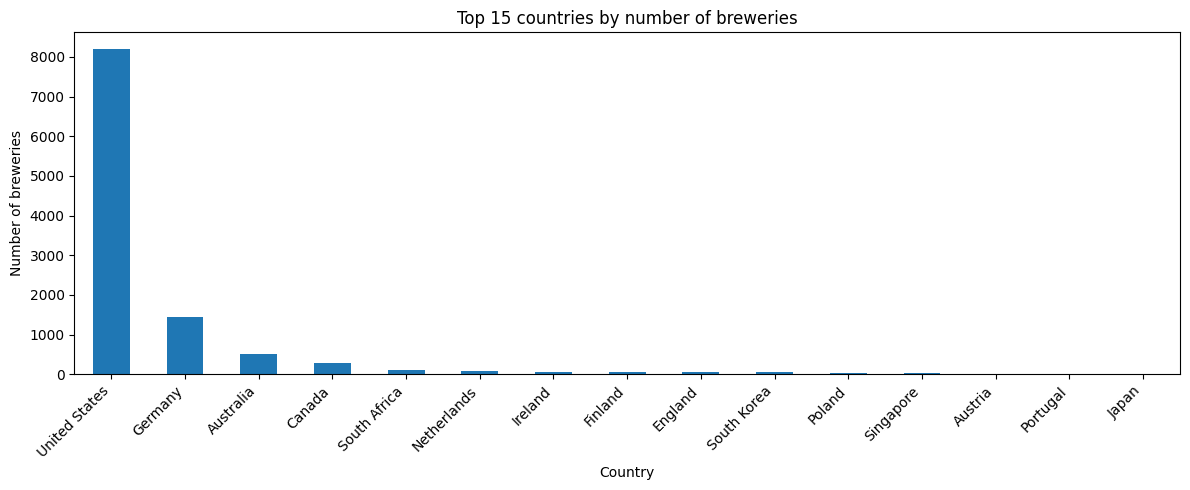

In [32]:
top_countries.plot(kind='bar', figsize=(12, 5), title='Top 15 countries by number of breweries')

plt.xlabel('Country')
plt.ylabel('Number of breweries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
df['brewery_type'].value_counts()

brewery_type
micro         5206
brewpub       3904
planning       641
closed         553
regional       239
contract       180
large          118
proprietor      67
taproom         47
bar             43
nano            21
cidery           7
beergarden       3
location         1
Name: count, dtype: int64